# Freight Market Dynamics - Dry Van Market - Models

In [23]:
import numpy as np
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import numpy as np
import seaborn as sns
from scipy.stats import skew, pearsonr
import statsmodels.api as sm

## Load data

In [3]:
df = pd.read_parquet("data/data_for_model.parquet") 

## Naive model equation with a possibly endogenous variable

In [ ]:
ind_vars = ['c', 'f']
dep_var = 'r'
x = df[ind_vars] 
y = df[dep_var]

x_const = sm.add_constant(x)

ols_naive = sm.OLS(y, x_const, missing = 'drop').fit()
print(ols_naive.summary())

## Extract resid and fitted values
resid = ols_naive.resid
fitted = ols_naive.fittedvalues

                            OLS Regression Results                            
Dep. Variable:                      r   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     1251.
Date:                Mon, 22 Sep 2025   Prob (F-statistic):               0.00
Time:                        12:20:46   Log-Likelihood:                -186.57
No. Observations:                6102   AIC:                             379.1
Df Residuals:                    6099   BIC:                             399.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4616      0.011     40.153      0.0

### Model evaluation (Diagnostic plots)

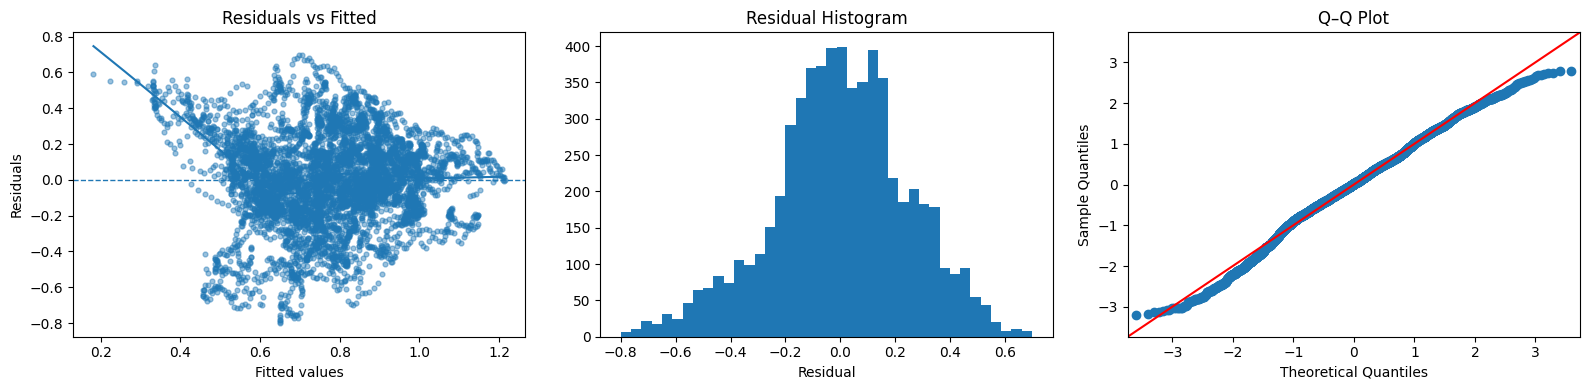

In [ ]:
## Residual diagnostics plots

resid  = ols_naive.resid
fitted = ols_naive.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Residuals vs Fitted + LOWESS
ax = axes[0]
ax.scatter(fitted, resid, alpha=0.45, s=12)
ax.axhline(0, linestyle='--', linewidth=1)
trend = lowess(resid, fitted, frac=0.3, return_sorted=True)
ax.plot(trend[:, 0], trend[:, 1], linewidth=1.5)
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted")

# 2) Histogram
axes[1].hist(resid, bins=40)
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Histogram")

# 3) Q–Q plot
sm.qqplot(resid, line='45', fit=True, ax=axes[2])
axes[2].set_title("Q–Q Plot")

fig.tight_layout()
plt.show()


### Residual tests:

* **Not normally distributed:**
    * Q–Q plot: The blue dots depart systematically from the red 45° line, especially at the tails → residuals are not normally distributed.
    * Histogram: Skewed to the right, not bell-shaped → confirms the Q–Q result.
    * Add more datapoints to fix it $\rightarrow$ OLS inference is asymptotically okay

* **Autocorrelation:**
    * Durbin–Watson (DW): DW ≈ 0.8, far from 2. That suggests strong positive autocorrelation in residuals.
    * Must include lagged variables or moving to time-series models (ARIMA, VAR, etc.) 

* OLS residuals violate the Gauss–Markov assumptions (normality and no autocorrelation).

* That doesn’t bias OLS coefficients, but standard errors, confidence intervals, and p-values become unreliable.

#### What do to next?

Since I  have a panel data (many market areas over time) **System GMM (Blundell–Bond) or Difference GMM (Arellano–Bond)** is appropriate:

* N is large, T is small–moderate,
* Regressors are endogenous/predetermined: capacity and rate,
* Use internal instruments (lags of the variables).
* Does not require external IVs. 
* rely on moment conditions (no serial corr. in errors, etc.). 
* Check AR(1)/AR(2) and Hansen/Sargan and limit instruments (collapse, restrict lags).


## System GMN Estimation
### Intuition
* Estimate two equations (endogenous variables) and then build a system from them.

* With two endogenous variables $y_{it} = \begin{bmatrix} r_{it} \\ c_{it} \end{bmatrix}$ and lag order 2:


$$
\begin{bmatrix} r_{it} \\ c_{it} \end{bmatrix}
=
A_1 \begin{bmatrix} r_{i,t-1} \\ c_{i,t-1} \end{bmatrix}
+
A_2 \begin{bmatrix} r_{i,t-2} \\ c_{i,t-2} \end{bmatrix}
+
B\,x_{it} + \alpha_i + \tau_t + u_{it}.
$$

- $(A_1, A_2)$ capture **own** and **cross** lag effects (the VAR dynamics).
- $(x_{it})$ are **exogenous** controls (e.g., $(f_t, f_{t-1})$).
- $(\alpha_i)$ are unit fixed effects; $(\tau_t)$ are time dummies.
- In a **panel** VAR we pool coefficients across \(i\) and typically use panel GMM to handle endogeneity of lagged \(y\).

Written as two separate equations (the rows of the system):

$$
\begin{aligned}
r_{it} &= a_{11}^{(1)} r_{i,t-1} + a_{12}^{(1)} c_{i,t-1}
        + a_{11}^{(2)} r_{i,t-2} + a_{12}^{(2)} c_{i,t-2}
        + \beta_r^\top x_{it} + \alpha_i^{r} + \tau_t^{r} + u_{it}^{r},\\[4pt]
c_{it} &= a_{21}^{(1)} r_{i,t-1} + a_{22}^{(1)} c_{i,t-1}
        + a_{21}^{(2)} r_{i,t-2} + a_{22}^{(2)} c_{i,t-2}
        + \beta_c^\top x_{it} + \alpha_i^{c} + \tau_t^{c} + u_{it}^{c}.
\end{aligned}
$$


That’s why a system GMM with $[r,c]$ has **two equations**: one with $r_{it}$ as the dependent variable and one with $(c_{it})$. Each equation provides one **row** of $(A_1)$ and $(A_2)$.

**Thus, we should evaluate the coefficients values and understand then.**

#### Post-estimation tests: What to monitor after each run:

* **instruments (aim ≤ # groups; your table shows 30 groups KMAs).**

* Hansen p-value ⇒ should be finite and not extreme (avoid ~1.00 or ~0.00).

* Arellano–Bond ⇒ AR(1) p < 0.05 (expected), AR(2) p > 0.10.


## Baseline Model - Full Model

In [ ]:
import numpy as np
np.NaN = np.nan 
from pydynpd import regression


df_filtered = df.copy()

df_filtered = df_filtered[df_filtered['year'] >= 2023].copy()

df_filtered.sort_values(['id','t'], inplace=True)

# pydynpd expects concrete ids and an integer-ish time index
df_filtered['t'] = df_filtered['t'].astype(int)

# Compute Equations
# Equation for r_t  (lags of r and c, exog f and L1.f)
cmd_r = 'r L(1:2).r L(1:2).c f L1.f | gmm(r, 2:5) gmm(c, 2:5) iv(f L1.f) | timedumm nolevel'
res_r = regression.abond(cmd_r, df_filtered, ['id','t'])

# Equation for c_t  (symmetric)
cmd_c = 'c L(1:2).r L(1:2).c f L1.f | gmm(r, 2:5) gmm(c, 2:5) iv(f L1.f) | timedumm nolevel'
res_c = regression.abond(cmd_c, df_filtered, ['id','t'])

# Look at results (tables include Hansen J and AB AR(1)/AR(2) tests)
print(res_r)   # r-equation summary
print(res_c)   # c-equation summary

# Get VAR (2) coefficient matrices A1, A2 from the two regressions
def coef(model, name, default=0.0):
    tbl = model.models[0].regression_table.set_index('variable')
    return float(tbl.loc[name, 'coefficient']) if name in tbl.index else default

A1 = np.array([[coef(res_r, 'L1.r'), coef(res_r, 'L1.c')],
               [coef(res_c, 'L1.r'), coef(res_c, 'L1.c')]])
A2 = np.array([[coef(res_r, 'L2.r'), coef(res_r, 'L2.c')],
               [coef(res_c, 'L2.r'), coef(res_c, 'L2.c')]])
print(A1)

# companion matrix & stability (like pvarstable)
k = 2
companion = np.block([[A1, A2],
                      [np.eye(k), np.zeros((k, k))]])
eigvals = np.linalg.eigvals(companion)
print("Eigenvalues:", eigvals)
print("Stable (all |λ|<1)?", np.all(np.abs(eigvals) < 1))


 Dynamic panel-data estimation, two-step difference GMM
 Group variable: id                                Number of obs = 405      
 Time variable: t                                  Min obs per group: 15    
 Number of instruments = 131                       Max obs per group: 15    
 Number of groups = 27                             Avg obs per group: 15.00 
+-------+------------+---------------------+------------+-----------+-----+
|   r   |   coef.    | Corrected Std. Err. |     z      |   P>|z|   |     |
+-------+------------+---------------------+------------+-----------+-----+
|  L1.r | 0.0306323  |      0.3737561      | 0.0819581  | 0.9346800 |     |
|  L2.r | -0.6536189 |      0.3183397      | -2.0532122 | 0.0400520 |  *  |
|  L1.c | 2.5020356  |      3.5115604      | 0.7125139  | 0.4761466 |     |
|  L2.c | -2.4242181 |      3.7246705      | -0.6508544 | 0.5151405 |     |
|   f   | 0.5999848  |      0.3774336      | 1.5896434  | 0.1119152 |     |
|  L1.f | 0.3900742  |      

## Model 2 - Drop instruments - Hansem test is bad / Nickel Bias

### Collapse Instruments (Roodman, 2009)
### Model 2.1 -  Keep weekly time dummies, but collapse and shorten the window

In [27]:
# diff-GMM (no level eq.), collapsed instruments, shorter windows (2:3)
cmd_r = 'r L(1:2).r L(1:2).c f L1.f | gmm(r, 2:3) gmm(c, 2:3) iv(f L1.f) | timedumm nolevel collapse'
res_r = regression.abond(cmd_r, df_filtered, ['id','t'])

cmd_c = 'c L(1:2).r L(1:2).c f L1.f | gmm(r, 2:3) gmm(c, 2:3) iv(f L1.f) | timedumm nolevel collapse'
res_c = regression.abond(cmd_c, df_filtered, ['id','t'])

print(res_r)   # r-equation summary
print(res_c)   # c-equation summary


 Dynamic panel-data estimation, two-step difference GMM
 Group variable: id                               Number of obs = 405      
 Time variable: t                                 Min obs per group: 15    
 Number of instruments = 21                       Max obs per group: 15    
 Number of groups = 27                            Avg obs per group: 15.00 
+-------+-------------+---------------------+------------+-----------+---+
|   r   |    coef.    | Corrected Std. Err. |     z      |   P>|z|   |   |
+-------+-------------+---------------------+------------+-----------+---+
|  L1.r |  -1.2666469 |      10.4840544     | -0.1208165 | 0.9038364 |   |
|  L2.r |  -0.1784288 |      0.3134021      | -0.5693286 | 0.5691332 |   |
|  L1.c | -23.2083099 |      89.6143672     | -0.2589798 | 0.7956508 |   |
|  L2.c |  25.0780244 |      96.8980988     | 0.2588082  | 0.7957832 |   |
|   f   |  -0.0854701 |      0.3163360      | -0.2701878 | 0.7870158 |   |
|  L1.f |  -0.0629423 |      0.2051740  

### Model 2.2 - — Drop weekly timedum dummies

In [28]:
cmd_r = 'r L(1:2).r L(1:2).c f L1.f | gmm(r, 2:3) gmm(c, 2:3) iv(f L1.f) |  collapse'
res_r = regression.abond(cmd_r, df_filtered, ['id','t'])

cmd_c = 'c L(1:2).r L(1:2).c f L1.f | gmm(r, 2:3) gmm(c, 2:3) iv(f L1.f) |  collapse'
res_c = regression.abond(cmd_c, df_filtered, ['id','t'])

# Look at results (tables include Hansen J and AB AR(1)/AR(2) tests)
print(res_r)   # r-equation summary
print(res_c)   # c-equation summary

 Dynamic panel-data estimation, two-step system GMM
 Group variable: id                              Number of obs = 405      
 Time variable: t                                Min obs per group: 15    
 Number of instruments = 9                       Max obs per group: 15    
 Number of groups = 27                           Avg obs per group: 15.00 
+------+------------+---------------------+------------+-----------+-----+
|  r   |   coef.    | Corrected Std. Err. |     z      |   P>|z|   |     |
+------+------------+---------------------+------------+-----------+-----+
| L1.r | 0.8621585  |      0.0791626      | 10.8909777 | 0.0000000 | *** |
| L2.r | -0.0424678 |      0.0933844      | -0.4547636 | 0.6492793 |     |
| L1.c | -1.3885237 |      0.7881680      | -1.7617102 | 0.0781183 |     |
| L2.c | 1.5041998  |      0.8572382      | 1.7547046  | 0.0793099 |     |
|  f   | -0.0080337 |      0.0288950      | -0.2780321 | 0.7809877 |     |
| L1.f | -0.0327634 |      0.0352011      | -0.9

### Model 2.3 - Monthly instruments

In [29]:
# build coarse time FE
dummies = pd.get_dummies(df_filtered[['month']].astype('category'),
                         drop_first=True, prefix=['m'])
df_fe = pd.concat([df_filtered, dummies], axis=1)
iv_fe = ' '.join(dummies.columns)  # space-separated list

cmd_r = f'r L(1:2).r L(1:2).c f  {iv_fe} | gmm(r, 2:3) gmm(c, 2:3) iv(f L1.f {iv_fe}) |  collapse'
res_r = regression.abond(cmd_r, df_fe, ['id','t'])

cmd_c = f'c L(1:2).r L(1:2).c f  {iv_fe} | gmm(r, 2:3) gmm(c, 2:3) iv(f L1.f {iv_fe}) |  collapse'
res_c = regression.abond(cmd_c, df_fe, ['id','t'])

print(res_r)   # r-equation summary
print(res_c)   # c-equation summary


 Dynamic panel-data estimation, two-step system GMM
 Group variable: id                               Number of obs = 405      
 Time variable: t                                 Min obs per group: 15    
 Number of instruments = 12                       Max obs per group: 15    
 Number of groups = 27                            Avg obs per group: 15.00 
+------+------------+---------------------+------------+-----------+-----+
|  r   |   coef.    | Corrected Std. Err. |     z      |   P>|z|   |     |
+------+------------+---------------------+------------+-----------+-----+
| L1.r | 1.0898750  |      0.0834843      | 13.0548465 | 0.0000000 | *** |
| L2.r | -0.1189802 |      0.0739030      | -1.6099507 | 0.1074086 |     |
| L1.c | 0.3913276  |      0.4737968      | 0.8259397  | 0.4088383 |     |
| L2.c | -0.4354429 |      0.5132366      | -0.8484251 | 0.3962013 |     |
|  f   | 0.0399808  |      0.0328373      | 1.2175413  | 0.2233983 |     |
| m_2  | 0.0186638  |      0.0038882      | 

### Model 2.4 - Quartely instruments

In [30]:
df_filtered['quarter'] = ((df_filtered['month']-1)//3 + 1).astype('int')
dummies = pd.get_dummies(df_filtered[['quarter']].astype('category'),
                         drop_first=True, prefix=['q'])
df_fe = pd.concat([df_filtered, dummies], axis=1)
iv_fe = ' '.join(dummies.columns)

cmd_r = f'r L(1:2).r L(1:2).c f  {iv_fe} | gmm(r, 2:3) gmm(c, 2:3) iv(f L1.f {iv_fe}) |  collapse'
res_r = regression.abond(cmd_r, df_fe, ['id','t'])

cmd_c = f'c L(1:2).r L(1:2).c f {iv_fe} | gmm(r, 2:3) gmm(c, 2:3) iv(f L1.f {iv_fe}) | collapse'
res_c = regression.abond(cmd_c, df_fe, ['id','t'])

print(res_r) 
print(res_c) 

 Dynamic panel-data estimation, two-step system GMM
 Group variable: id                               Number of obs = 405      
 Time variable: t                                 Min obs per group: 15    
 Number of instruments = 10                       Max obs per group: 15    
 Number of groups = 27                            Avg obs per group: 15.00 
+------+------------+---------------------+------------+-----------+-----+
|  r   |   coef.    | Corrected Std. Err. |     z      |   P>|z|   |     |
+------+------------+---------------------+------------+-----------+-----+
| L1.r | 0.9040805  |      0.0824274      | 10.9682087 | 0.0000000 | *** |
| L2.r | -0.0875291 |      0.0826253      | -1.0593497 | 0.2894405 |     |
| L1.c | -1.1940389 |      0.8815725      | -1.3544421 | 0.1755954 |     |
| L2.c | 1.2772092  |      0.9606591      | 1.3295134  | 0.1836786 |     |
|  f   | -0.0366238 |      0.0498734      | -0.7343344 | 0.4627449 |     |
| q_2  | -0.0105543 |      0.0032080      | 

### Model 2.5 - H2 Monthly instruments

In [31]:
# Make a Jul–Dec indicator
df_fe = df_filtered.copy()
df_fe['H2'] = (df_fe['month'] >= 7).astype('int8')   # 1 if month ∈ {7,…,12}

# 2) use it as an exogenous regressor and instrument
cmd_r = 'r L(1:2).r L(1:2).c f H2 | gmm(r, 2:3) gmm(c, 2:3) iv(f L1.f H2) | collapse'
res_r = regression.abond(cmd_r, df_fe, ['id','t'])

cmd_c = 'c L(1:2).r L(1:2).c f H2 | gmm(r, 2:3) gmm(c, 2:3) iv(f L1.f H2) | collapse'
res_c = regression.abond(cmd_c, df_fe, ['id','t'])

print(res_r)
print(res_c)


 Dynamic panel-data estimation, two-step system GMM
 Group variable: id                               Number of obs = 405      
 Time variable: t                                 Min obs per group: 15    
 Number of instruments = 10                       Max obs per group: 15    
 Number of groups = 27                            Avg obs per group: 15.00 
+------+------------+---------------------+------------+-----------+-----+
|  r   |   coef.    | Corrected Std. Err. |     z      |   P>|z|   |     |
+------+------------+---------------------+------------+-----------+-----+
| L1.r | 0.8898958  |      0.0741044      | 12.0086699 | 0.0000000 | *** |
| L2.r | -0.0701987 |      0.0802086      | -0.8752011 | 0.3814645 |     |
| L1.c | -1.3437122 |      0.8430082      | -1.5939492 | 0.1109474 |     |
| L2.c | 1.4490153  |      0.9180264      | 1.5784027  | 0.1144731 |     |
|  f   | -0.0126073 |      0.0377981      | -0.3335441 | 0.7387236 |     |
|  H2  | 0.0000000  |      0.0000000      | 

Best model was 2.3 Monthly Instruments, but the problem is that we need to use less than 30 datapoints (ids)

## System Stability Test

In [34]:
# build coarse time FE
dummies = pd.get_dummies(df_filtered[['month']].astype('category'),
                         drop_first=True, prefix=['m'])
df_fe = pd.concat([df_filtered, dummies], axis=1)
iv_fe = ' '.join(dummies.columns)  # space-separated list

cmd_r = f'r L(1:2).r L(1:2).c f  {iv_fe} | gmm(r, 2:3) gmm(c, 2:3) iv(f L1.f {iv_fe}) |  collapse'
res_r = regression.abond(cmd_r, df_fe, ['id','t'])

cmd_c = f'c L(1:2).r L(1:2).c f  {iv_fe} | gmm(r, 2:3) gmm(c, 2:3) iv(f L1.f {iv_fe}) |  collapse'
res_c = regression.abond(cmd_c, df_fe, ['id','t'])

print(res_r)   # r-equation summary
print(res_c)   # c-equation summary

## Stability tests

# Get  lagged coefficient matrices A1, A2 from the two regressions
def coef(model, name, default=0.0):
    tbl = model.models[0].regression_table.set_index('variable')
    return float(tbl.loc[name, 'coefficient']) if name in tbl.index else default

A1 = np.array([[coef(res_r, 'L1.r'), coef(res_r, 'L1.c')],
               [coef(res_c, 'L1.r'), coef(res_c, 'L1.c')]])
A2 = np.array([[coef(res_r, 'L2.r'), coef(res_r, 'L2.c')],
               [coef(res_c, 'L2.r'), coef(res_c, 'L2.c')]])
print(A1)

# companion matrix & stability (like pvarstable)
k = 2
companion = np.block([[A1, A2],
                      [np.eye(k), np.zeros((k, k))]])
eigvals = np.linalg.eigvals(companion)
print("Eigenvalues:", eigvals)
print("Stable (all |λ|<1)?", np.all(np.abs(eigvals) < 1))



 Dynamic panel-data estimation, two-step system GMM
 Group variable: id                               Number of obs = 405      
 Time variable: t                                 Min obs per group: 15    
 Number of instruments = 12                       Max obs per group: 15    
 Number of groups = 27                            Avg obs per group: 15.00 
+------+------------+---------------------+------------+-----------+-----+
|  r   |   coef.    | Corrected Std. Err. |     z      |   P>|z|   |     |
+------+------------+---------------------+------------+-----------+-----+
| L1.r | 1.0898750  |      0.0834843      | 13.0548465 | 0.0000000 | *** |
| L2.r | -0.1189802 |      0.0739030      | -1.6099507 | 0.1074086 |     |
| L1.c | 0.3913276  |      0.4737968      | 0.8259397  | 0.4088383 |     |
| L2.c | -0.4354429 |      0.5132366      | -0.8484251 | 0.3962013 |     |
|  f   | 0.0399808  |      0.0328373      | 1.2175413  | 0.2233983 |     |
| m_2  | 0.0186638  |      0.0038882      | 

Model outputs:

**1. Coeficients interpretation:**
* Dynamic coefficient (lag of dep. var.) should typically be between 0 and 1 in economic models;
*  L1.r strongly positive, L2.r slightly negative, consistent with short-term persistence but some mean reversion.

**2. Instrument validity (Hansen J test (or Sargan if homoskedastic errors assumed)):**
* Hypothesis Null: instruments are valid (uncorrelated with the error, correctly excluded).
* You want a p-value not too small (otherwise reject instrument validity), but also not extremely close to 1 (which may suggest instrument proliferation/weak identification).

* Model Results: 

    * First regression: Hansen p = 0.022 → borderline rejection of validity.
    * Second regression: Hansen p = 0.007 → stronger rejection.

* Still need to find a way to reduce instruments

**3. Serial correlation of residuals**

Arellano–Bond AR(1):
* Always expect AR(1) in first differences (p < 0.05).
* AR(1) is significant (p = 0.007 in the first regression), which is expected.

Arellano–Bond AR(2):
* Null: no 2nd-order serial correlation.
* This is critical: you need p > 0.05 to trust the model.

Model Results: 
* AR(2) p = 0.094 (first regression) and p = 0.331 (second regression) $\rightarrow$ That’s acceptable.

### Next steps:
System GMM is struggling a bit (Hansen p-values too low, small T, borderline instrument validity). 

A Panel VAR (PVAR) is a good alternative when:
* All variables (rate, capacity, fuel) are potentially endogenous.
* Want to capture dynamic feedback across them instead of treating one as strictly dependent and the others as regressors.
* Care about impulse–response functions (IRFs) and variance decompositions, not just coefficients.